# 140. BERT의 Word Piece Tokenization 이해

- HuggingFace의 BERT library install
```
!pip install transformers
```

## Simple Tokenization

In [3]:
# !pip install transformers

In [4]:
import torch
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertTokenizer

In [6]:
text = ["Don't you love 🤗 Transformers? We sure do.",
        "I have a new GPU!"]

## Bert 의 pre-trained Subword Tokenizer
- bert-base-multilingual-cased model
- SentencePiece Tokenization

In [7]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

for txt in text:
    print(tokenizer.tokenize(txt))

Downloading:   0%|          | 0.00/996k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/625 [00:00<?, ?B/s]

['Don', "'", 't', 'you', 'love', '[UNK]', 'Transformers', '?', 'We', 'sure', 'do', '.']
['I', 'have', 'a', 'new', 'GPU', '!']


In [10]:
for i in range(len(text)):
    print(text[i])
    print(tokenizer.encode(text[i]))
    print()

Don't you love 🤗 Transformers? We sure do.
[101, 11740, 112, 188, 13028, 16138, 100, 64562, 136, 12865, 62452, 10149, 119, 102]

I have a new GPU!
[101, 146, 10529, 169, 10751, 102345, 106, 102]



In [11]:
tokenizer.decode([101, 11740, 112, 188, 13028, 16138, 100, 64562, 136, 12865, 62452, 10149, 119, 102])

"[CLS] Don't you love [UNK] Transformers? We sure do. [SEP]"

## BERT SentencePiece Tokenizer Vocaburary 검토

- `bert-base-uncase-multilingual` model의 vocabulary
    - 0 - [PAD]
    - 100 - [UNK]
    - 101 - [CLS]
    - 102 - [SEP]
    - 103 - [MASK]

In [12]:
vocabs = list(tokenizer.vocab.items())

print(len(vocabs))
vocabs[0], vocabs[100:104]

119547


(('[PAD]', 0),
 [('[UNK]', 100), ('[CLS]', 101), ('[SEP]', 102), ('[MASK]', 103)])

In [13]:
vocabs[24585:24595], vocabs[-1]

([('befinden', 24585),
  ('берегу', 24586),
  ('masyarakat', 24587),
  ('детей', 24588),
  ('धर्म', 24589),
  ('setiap', 24590),
  ('mulai', 24591),
  ('იგი', 24592),
  ('Stevens', 24593),
  ('##ität', 24594)],
 ('##𩾌', 119546))

## Bert SentencePiece Tokenizer vocabulary의 character 갯수

In [14]:
one_chars = []
one_char_hashes = []
two_chars = []

for token in tokenizer.vocab.keys():
    if len(token) == 1:
        one_chars.append(token)
    if len(token) == 2:
        two_chars.append(token)
    if len(token) == 3 and token[:2] == '##':
        one_char_hashes.append(token)

In [15]:
print(one_chars[:100])

['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~', '¡', '¢', '£', '¥', '¦', '§', '¨']


In [16]:
print(one_char_hashes[:100])

['##s', '##e', '##a', '##n', '##i', '##t', '##r', '##o', '##u', '##m', '##y', '##l', '##d', '##k', '##а', '##и', '##е', '##у', '##h', '##g', '##м', '##н', '##ی', '##ы', '##z', '##о', '##é', '##c', '##т', '##і', '##х', '##ة', '##й', '##я', '##ه', '##p', '##ה', '##j', '##ا', '##ó', '##b', '##의', '##ي', '##ă', '##v', '##ו', '##ς', '##ת', '##ت', '##к', '##с', '##л', '##р', '##에', '##י', '##в', '##í', '##f', '##ن', '##ю', '##ą', '##을', '##の', '##د', '##á', '##ر', '##x', '##م', '##ı', '##2', '##S', '##A', '##이', '##д', '##1', '##à', '##г', '##ų', '##ь', '##C', '##w', '##3', '##ë', '##은', '##が', '##ी', '##0', '##ם', '##년', '##ل', '##ę', '##ը', '##ן', '##ů', '##4', '##ä', '##는', '##п', '##ب', '##T']


In [17]:
print(two_chars[:100])

['de', 'in', 'of', 'la', 'en', 'to', 'un', 'di', 'на', 'is', 'el', 'se', 'et', 'na', 'on', 'är', 'le', 'da', 'je', 'as', 'sa', 'do', '10', 'an', 'il', 'by', 'og', 'La', 'at', 'er', 'al', 'In', 'du', 'av', '12', 'De', 'no', '11', 'es', '20', 'su', 'ja', 'km', '15', 'om', 'في', 'im', 'på', '18', 'El', 'ha', '24', 'за', 'در', 'En', '30', '14', '13', '16', 'је', 'és', 'au', '25', 'he', 'em', '19', 'it', '17', '°C', 'се', 'Le', 'Il', 'من', 'um', 'si', '21', 'по', 'op', 'zu', '22', 'od', 'An', '26', 'של', 'va', 've', 'به', '23', 'là', 'от', 'II', 'za', 'до', 'or', 'be', '28', 'He', 'az', 'te', '27']


In [33]:
# 1600 - 2021 의 연도가 얼마나 포함되어 있는지 count
count = 0 
for i in range(1600, 2021):
    if str(i) in tokenizer.vocab:
        count += 1

print('Vocab includes {:,} of 421 dates from 1600 - 2021'.format(count))

Vocab includes 421 of 421 dates from 1600 - 2021


In [35]:
# vocabulary에 숫자가 얼마나 포함되어 있는지 
count = 0

for token in tokenizer.vocab.keys():
    # 숫자면 +1
    if token.isdigit():
        count += 1  
        if len(token) > 10:
            print(token)

print('Vocab includes {:,} numbers.'.format(count))

9780521872386
9789004244870
Vocab includes 2,347 numbers.


In [36]:
for token in tokenizer.vocab.keys():
    if len(token) > 4 and re.search('[가-힣]', token):
        print(token)

##하였다
##되었다
##적으로
2014년
2012년
2016년
2011년
2013년
2010년
2015년
2009년
2008년
2017년
2007년
##에서는
2018년
2006년
대한민국의
##대학교
2005년
2004년
##하였고
2002년
2003년
##하면서
2001년
2000년
1999년
1998년
##되었고
1996년
##했으며
##었으며
1997년
##하였으며
1995년
##등학교
##되었으며
##었으나
##이었다
##쪽으로
1994년
##광역시
##들에게
##용하여
1992년
##장으로
1993년
##하기도
##위원회
1987년
##었지만
1991년
##역이다
1990년
##식으로
##었는데
##였으나
서울특별시
##드라마
1988년
1989년
##원으로
일반적으로
##상으로
1986년
##년부터
##정에서
##전에서
1984년
1985년
##로부터
##장하는
1983년
지정되었다
##년에는
##용된다
##장에서
1981년
##되면서
##능하다
1980년
1982년
##쪽으로는
##인이다
##공화국
애니메이션
##았으며
##성되어
##재한다
##프리카
##했지만
##정되었다
##어졌다
1945년


##  bert-base-multilingual-cased model 의 word 길이 시각화 

In [37]:
data = pd.DataFrame([len(token) for token in tokenizer.vocab.keys()], columns=["count"])                   

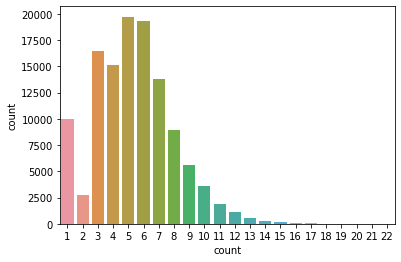

In [38]:
sns.countplot(x="count", data=data);